# 03 — Experiment A: No Wildfire Risk
Predicts 2021 insurance premiums using only insurance + census features.

In [1]:
import sys
sys.path.append('..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from src.preprocessing import load_data, drop_leakage_columns, fix_target, encode_booleans, split_train_test
from src.features import build_all_features
from src.models import run_experiment
from src.utils import save_metrics
from src.config import BASE_FEATURES, LAG_FEATURES, TARGET, FIGURES_DIR, RANDOM_SEED

EXPERIMENT_NAME = 'A - No Wildfire Risk'
FEATURES_A = BASE_FEATURES + LAG_FEATURES

df = load_data()
df = drop_leakage_columns(df)
df = fix_target(df)
df = encode_booleans(df)
df = build_all_features(df)
train, test = split_train_test(df)

available = [f for f in FEATURES_A if f in df.columns]
missing_f = [f for f in FEATURES_A if f not in df.columns]
if missing_f:
    print(f'Warning: {len(missing_f)} features not found: {missing_f}')
print(f'Using {len(available)} features')

metrics_A = run_experiment(train, test, available, EXPERIMENT_NAME)
results_A = save_metrics(metrics_A, 'experiment_A_metrics.csv')
print(results_A.to_string(index=False))

train_clean = train[available + [TARGET]].dropna()
test_clean  = test[available + [TARGET]].dropna()
rf = RandomForestRegressor(n_estimators=200, random_state=RANDOM_SEED, n_jobs=-1)
rf.fit(train_clean[available], train_clean[TARGET])
preds = rf.predict(test_clean[available])

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
plt.figure(figsize=(7,6))
plt.scatter(test_clean[TARGET], preds, alpha=0.3, s=10, color='steelblue')
mx = max(test_clean[TARGET].max(), preds.max())
plt.plot([0, mx], [0, mx], 'r--', lw=1.5, label='Perfect')
plt.xlabel('Actual Earned Premium ($)')
plt.ylabel('Predicted ($)')
plt.title('Exp A — Actual vs Predicted (Random Forest)')
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'exp_A_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Experiment A complete')

✅ Loaded: 47,033 rows × 76 columns
✅ Dropped 28 leakage/null columns → 48 remain
⚠️  Clipping 7 negative 'Earned Premium' values to 0
✅ Encoded 6 boolean columns to int
✅ Feature engineering complete → 56 total columns
✅ Split → Train: 33,689 rows | Test: 13,344 rows
Using 40 features

  Experiment : A - No Wildfire Risk
  Train rows : 33,689  |  Test rows: 13,344
  Features   : 40
    Naive (Lag-1)             MAE=     866,788  RMSE=   2,247,699  R2=-0.7193  MAPE=7956853.64%
    Ridge                     MAE=     252,793  RMSE=     648,091  R2= 0.8571  MAPE=3494542.63%
    Random Forest             MAE=      62,861  RMSE=     272,481  R2= 0.9747  MAPE= 71.45%
    Gradient Boosting         MAE=      79,010  RMSE=     245,963  R2= 0.9794  MAPE=145505.94%
💾 Saved metrics → /Users/aishwaryadas/deloitte-challenge-2026/insurance-model/results/metrics/experiment_A_metrics.csv
          Experiment             Model       MAE       RMSE      R2       MAPE
A - No Wildfire Risk     Naive (Lag-1)

ValueError: Found array with 0 sample(s) (shape=(0, 40)) while a minimum of 1 is required by RandomForestRegressor.

✅ Loaded: 47,033 rows × 76 columns
✅ Dropped 28 leakage/null columns → 48 remain
⚠️  Clipping 7 negative 'Earned Premium' values to 0
✅ Encoded 6 boolean columns to int
✅ Feature engineering complete → 56 total columns
✅ Split → Train: 33,689 rows | Test: 13,344 rows
Using 40 features

  Experiment : A - No Wildfire Risk
  Train rows : 33,689  |  Test rows: 13,344
  Features   : 40
    Naive (Lag-1)             MAE=     866,788  RMSE=   2,247,699  R2=-0.7193  MAPE=7956853.64%
    Ridge                     MAE=     252,793  RMSE=     648,091  R2= 0.8571  MAPE=3494542.63%
    Random Forest             MAE=      62,861  RMSE=     272,481  R2= 0.9747  MAPE= 71.45%
    Gradient Boosting         MAE=      79,010  RMSE=     245,963  R2= 0.9794  MAPE=145505.94%
💾 Saved metrics → /Users/aishwaryadas/deloitte-challenge-2026/insurance-model/results/metrics/experiment_A_metrics.csv
          Experiment             Model       MAE       RMSE      R2       MAPE
A - No Wildfire Risk     Naive (Lag-1)

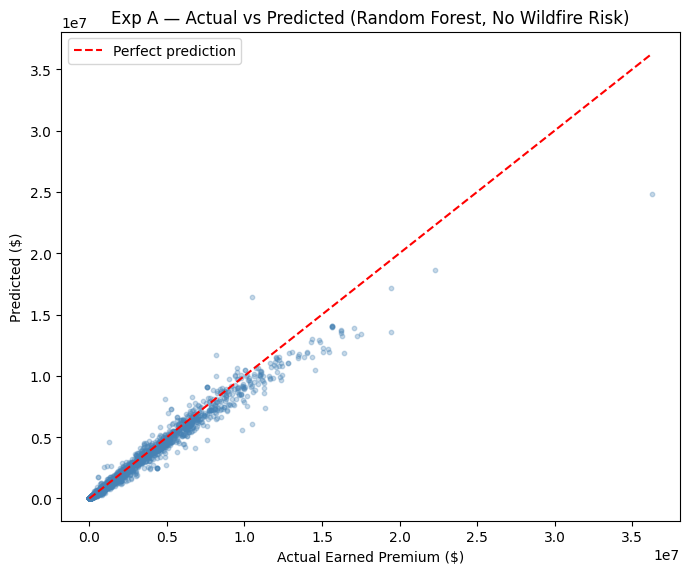

✅ Experiment A complete


In [3]:
import sys
sys.path.append('..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from src.preprocessing import load_data, drop_leakage_columns, fix_target, encode_booleans, split_train_test
from src.features import build_all_features
from src.models import run_experiment
from src.utils import save_metrics
from src.config import BASE_FEATURES, LAG_FEATURES, TARGET, FIGURES_DIR, RANDOM_SEED

EXPERIMENT_NAME = 'A - No Wildfire Risk'
FEATURES_A = BASE_FEATURES + LAG_FEATURES

# ── Load and prepare ──────────────────────────────────────────────────────────
df = load_data()
df = drop_leakage_columns(df)
df = fix_target(df)
df = encode_booleans(df)
df = build_all_features(df)
train, test = split_train_test(df)

available = [f for f in FEATURES_A if f in df.columns]
missing_f = [f for f in FEATURES_A if f not in df.columns]
if missing_f:
    print(f'Warning: {len(missing_f)} features not found: {missing_f}')
print(f'Using {len(available)} features')

# ── Run experiment ────────────────────────────────────────────────────────────
metrics_A = run_experiment(train, test, available, EXPERIMENT_NAME)
results_A = save_metrics(metrics_A, 'experiment_A_metrics.csv')
print(results_A.to_string(index=False))

# ── Chart: Actual vs Predicted ────────────────────────────────────────────────
# Impute nulls the same way run_experiment does
train_c = train[available + [TARGET]].copy()
test_c  = test[available + [TARGET]].copy()
for col in available:
    median_val = train_c[col].median()
    train_c[col] = train_c[col].fillna(median_val)
    test_c[col]  = test_c[col].fillna(median_val)
train_c = train_c.dropna(subset=[TARGET])
test_c  = test_c.dropna(subset=[TARGET])

rf = RandomForestRegressor(n_estimators=200, random_state=RANDOM_SEED, n_jobs=-1)
rf.fit(train_c[available], train_c[TARGET])
preds = rf.predict(test_c[available])

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
plt.figure(figsize=(7, 6))
plt.scatter(test_c[TARGET], preds, alpha=0.3, s=10, color='steelblue')
mx = max(test_c[TARGET].max(), preds.max())
plt.plot([0, mx], [0, mx], 'r--', lw=1.5, label='Perfect prediction')
plt.xlabel('Actual Earned Premium ($)')
plt.ylabel('Predicted ($)')
plt.title('Exp A — Actual vs Predicted (Random Forest, No Wildfire Risk)')
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'exp_A_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Experiment A complete')
